<a href="https://colab.research.google.com/github/sejal-oli7/python/blob/main/python%20/%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
!wget $data

--2026-09-20 07:35:29--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   1.41M  --.-KB/s    in 0.02s   

2026-09-20 07:35:29 (71.3 MB/s) - ‘data.csv’ saved [1475504/1475504]



In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df['make'].str.lower().str.replace(' ', '_')

,make
0,bmw
1,bmw
2,bmw
3,bmw
4,bmw
...,...
11909,acura
11910,acura
11911,acura
11912,acura


In [7]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [8]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [9]:
df.dtypes

,0
make,object
model,object
year,int64
engine_fuel_type,object
engine_hp,float64
engine_cylinders,float64
transmission_type,object
driven_wheels,object
number_of_doors,float64
market_category,object


In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [11]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

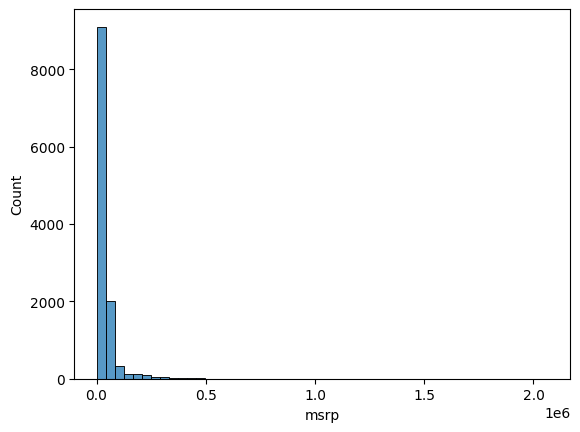

In [13]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

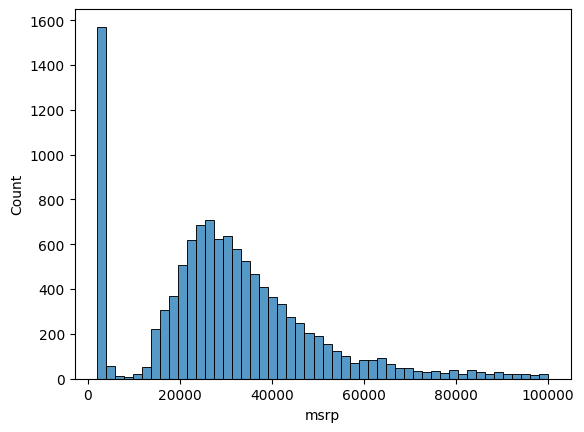

In [14]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

This left part of the histogram, there is a starge peak of cars that cost around 1000, probably the minimal price possible to put on the platform. Then the number of cards slowly grows up to around 25000, i.e almost 700 cars cost that much proce. and after that it foes down as the price grows.





This unsual distribution is not good for machine learning, the long tail will confuse the model and screw things up. Thus we want to get rid of it, and the usual trick is to apply the log function for that price.

In [15]:
df.isnull().sum()

,0
make,0
model,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,3742


Validation framework:

dataset is cleaned, explored, we need to split the dataset into train, validation and testing parts, we need to prepare the traget variable for each part. We do it manually using pandas and numpy

Calculating the size of the parts
- we will do 60/20/20 split, so we first need to calculate how many records 20% actually is. Our dataframe has almost 12k records, so 20% of that would be
approx 2400.  we want a whole number of records, not a fraction like 2382.58. Thus, we will cut the fraction off with int()

In [16]:
n = len(df)
n

11914

In [17]:
n_val = int(n*0.2)
n_test = int (n * 0.2)
# n_train = int(n * 0.6)
n_train = n - n_val - n_test

In [18]:
n, n_val, n_test, n_train

(11914, 2382, 2382, 7150)

**Taking a part of the dtaframe with iloc**
Now, we know the sizes, and we need to take a part of the dataframe of that size.  For that we use ```iloc```, which we have already studied.
we usually give it a list of indices, but it also accespts range.
eg to get first 10 records

In [19]:
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


Take away: i used range, it gives 10 records, inclusive of record 0 but exclusive of record 10.

So the simplest thing we can do is cut the dataframe sequentially

In [20]:
df.head(20)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


In [21]:
df_val = df.iloc[:n_val]
df_test = df.iloc[n_val:n_val + n_test]
df_train = df.iloc[n_val + n_test:]

we noticed here, while splitting sequentially, the dataset is being filtered by the column name, make. So, we validation contains only bmw, training contains only one specific car, and same for testing. which is a red flag.

Thats the reason, ALWAYS, SHUFFLE THE DATASET BEFORE YOU PASS IT FOR MODEL TRAINING

We need to shuffle the dataset,  we can use np.random.shuffle

In [22]:
n, n_train, n_val, n_test

(11914, 7150, 2382, 2382)

In [23]:
idx = np.arange(n)
np.random.shuffle(idx)

In [24]:
#@ Now, we index the dataframe with the shuffled numbers instead of sequential ranges

In [25]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

Still theres a problem??????
The problem is, everytime, you run this code,
 you will get a new random data for each df_train,test, val.

 you will end of developing a model under this condition, when the model accuracy is not satified, you need to retrain the model with tweaked parameter. But this time, when you split, again the data is shuffled, that means, you wont be able to get the same data that have been used previously

In [26]:
np.random.seed(2)

idx = np.arange(n)
np.random.shuffle(idx)

In [27]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [28]:
len(df_train), len(df_val), len(df_test)


(7150, 2382, 2382)

In [29]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


looking at the dataset, we encountered that, the index of the dataframe is also shuffled, we can reset the index for this scenario

In [30]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [31]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


So far, we have completed data cleaning and made it ready for model training

- our task was to predict the price of a car

We will start with very basic model, call it as linear regression model.

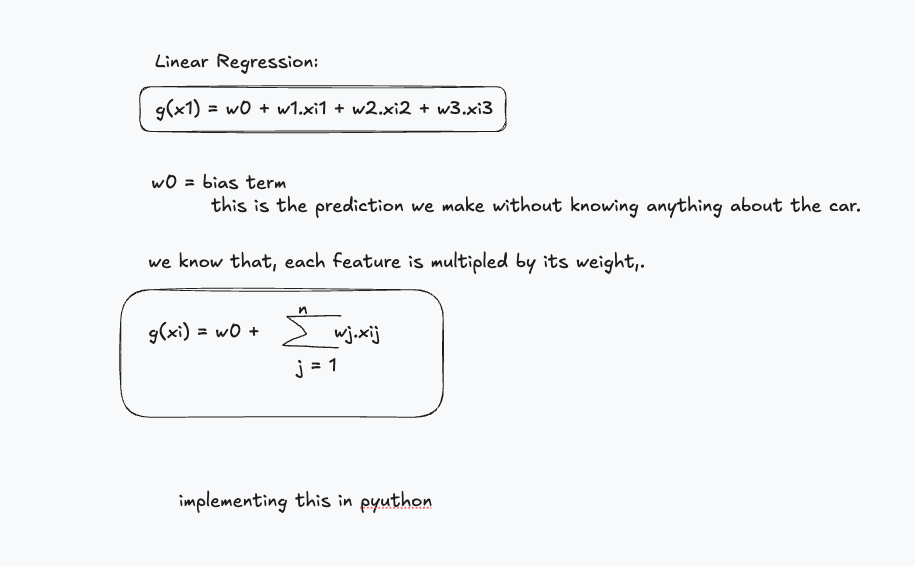

In [32]:
#@ We have feature vector xi, the bias term, w0 and a vector w with a weight for each feature

xi = [132, 25, 2031]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [33]:
#@ Lets create a function to implement the above output function
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j] # pred = w0 + 0.01 * 453

    return pred

In [34]:
#@ Lets apply this mathematics to our car

linear_regression(xi)

13.552

In [35]:
np.expm1(13.552)

np.float64(768348.5101897252)

In [36]:
7.17 + 453*0.01 + 11*0.04 + 86*0.002

12.312

Lets implement linear regression in our system


In [37]:
df_train.head(15)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
5,volkswagen,rabbit,2008,regular_unleaded,170.0,5.0,manual,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,29,22,873,17575
6,bentley,continental_gtc,2013,premium_unleaded_(required),500.0,8.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,convertible,24,14,520,191400
7,bmw,6_series,2015,premium_unleaded_(required),315.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,coupe,32,21,3916,76100
8,maybach,57,2012,premium_unleaded_(required),543.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury",large,sedan,16,10,67,379050
9,ford,f-150_heritage,2004,regular_unleaded,202.0,6.0,manual,four_wheel_drive,2.0,NaN,large,regular_cab_pickup,18,13,5657,26030


Preparing y and removing msrp:

the df will be used to make the feature matrix X, The target y comes from the msrp column and we already know that we need to apply some mathematical function, to handle its distribution.

Lets apply log function to msrp column

In [38]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [39]:
y_train = np.log1p(df_train.msrp.values)
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978])

In [40]:
np.expm1(9.887663)

np.float64(19684.99995690426)

In [41]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [42]:
# del df_train['msrp']
# del df_val['msrp']
# del df_test['msrp']

## Linear Regression

In [43]:
xi = [453, 11, 86] # 453 horse power, 11:mileage per gallon, 86 popularity score of 10th record,
w0 = 7.17 # bias
w = [0.01, 0.04, 0.002] # weights
# w0 and w are assumption for the above car rolce royes

Linear Regression in the form of Vector:
just now, we observed the prediction of a single car. What do we need to do to predict the price of entire dataset at once?

Dot product:
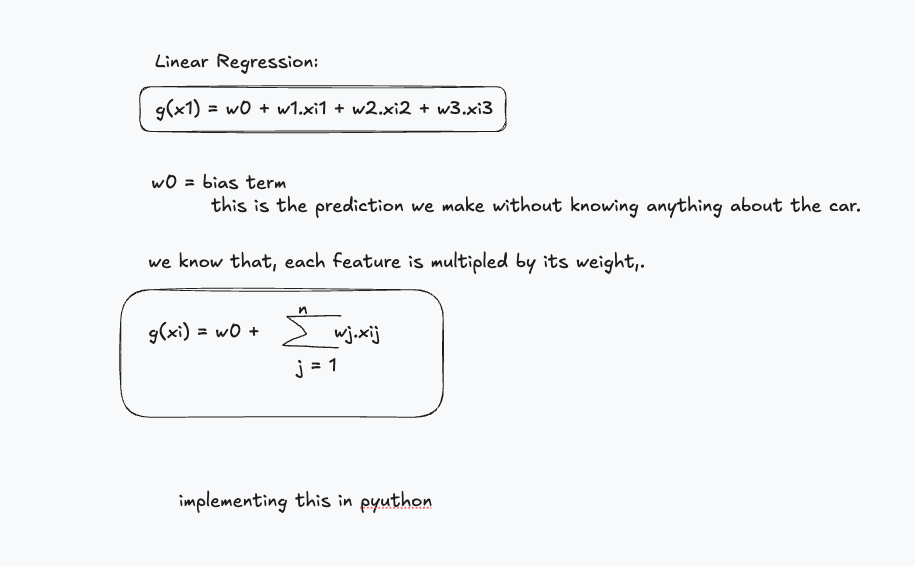

We can also represent the above expression for g(xi) in the form of vectors

``` g(xi) = w0 + xi^Tw```

In [44]:
#@ If we apply this compact notation in our system

def dot(xi, w):
   n = len(xi)

   res = 0.0

   for j in range(n):
      res = res + xi[j] * w[j]

   return res

In [45]:
#@ Now implemeting linear regression function

def linear_regression(xi):
   return w0 + dot(xi, w)

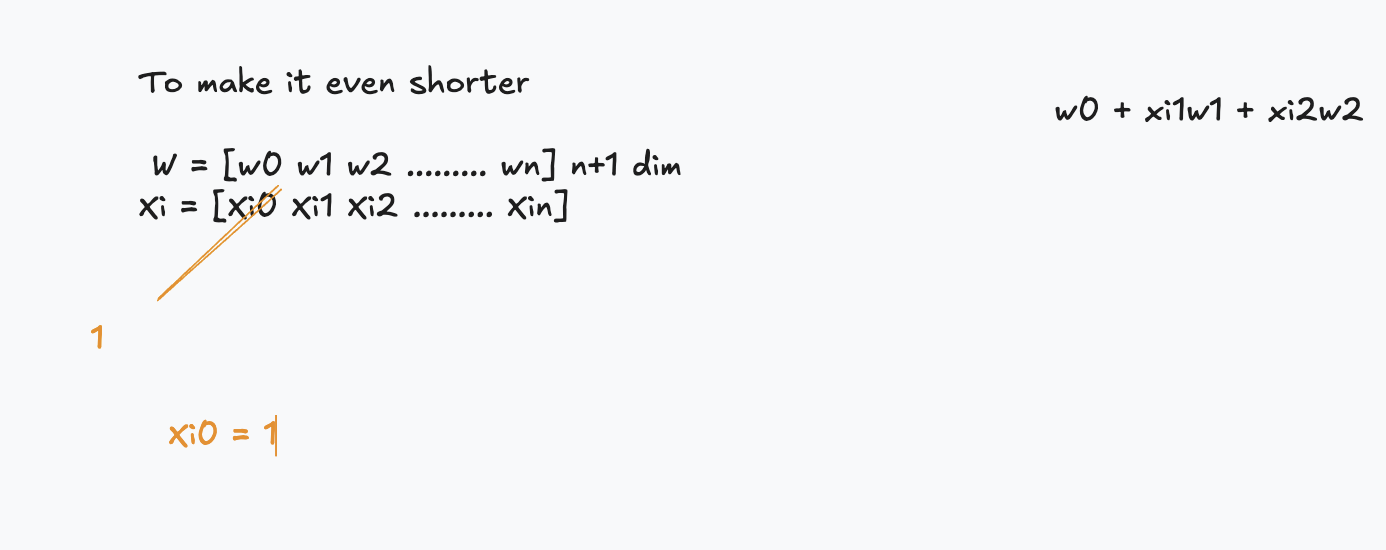

wT Xi = XiTw

In [46]:
# Xi = Xi0 + Xi
# Xi0 = 1

# Xi = [1] + Xi

We can make a feature in a way that

we will have new values of w and Xi



In [47]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

similarly, we can also prepend 1 to xi and then taking dot product of these two vectors xi and w like below

In [48]:
def linear_regression(xi):
  xi = [1] + xi
  return dot(xi, w_new)

In [49]:
linear_regression(xi)

12.312

If we need to implement linear regressions for all the cars,
we have already a matrix X. since we are using fictional features,

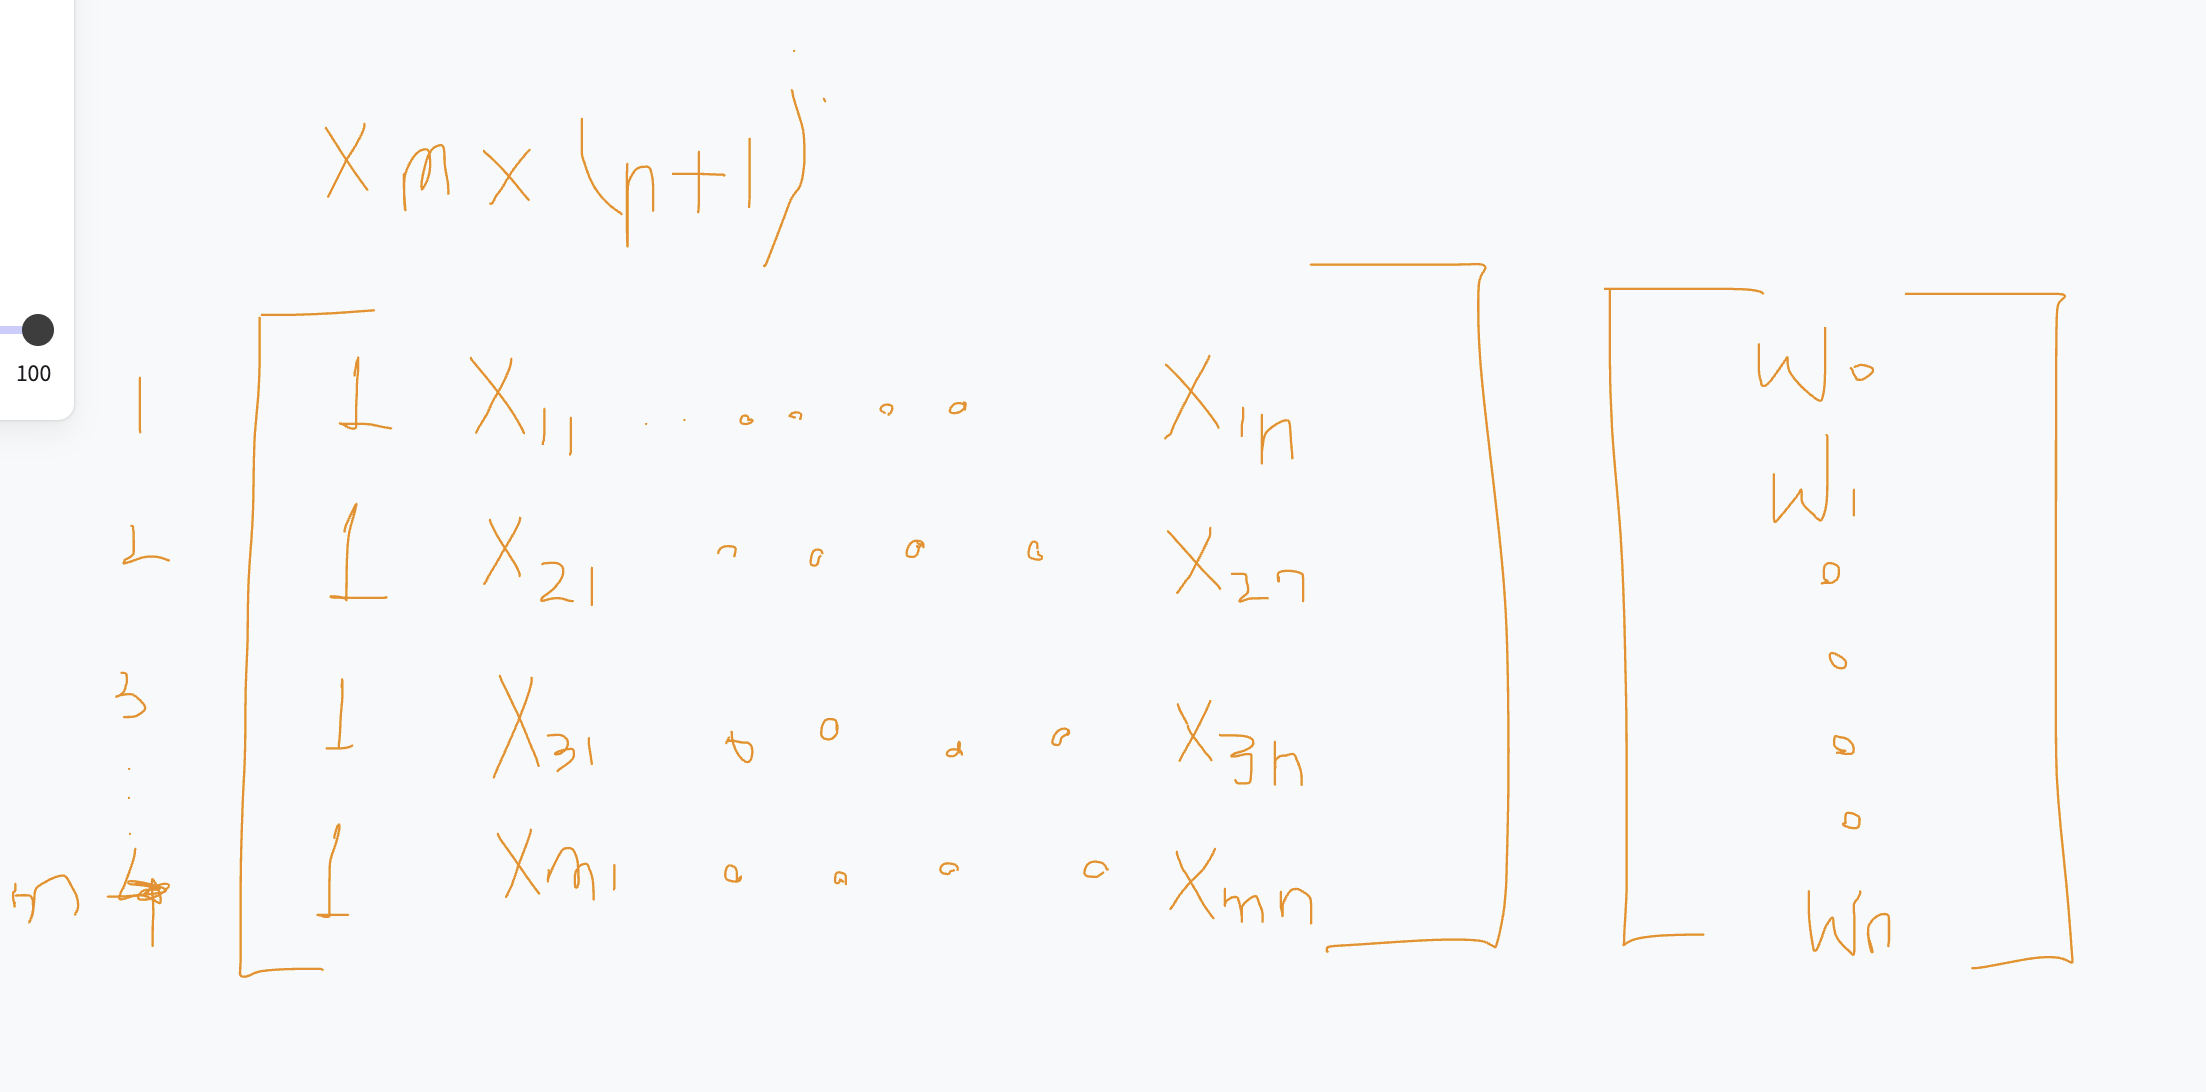

For us, X has m rows and n+1 columns. Thus, what we need is that,
take each row of this matrix, do the dot product of that row with vector of weight w. This gives us the prediction for that car.

So, doing this for all the rows,, all the cars we have in the dataset gives us vector of prediction y.
y_pred

That means, matrix X multipled with vector w will give you y,

Xw nearly equals to y

Lets implement, 3 cars and prepend 1 to each feature vector, then put them together into a matrix, and turn it into numpy array to process it

In [50]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

In [51]:
X = [x1, x2, x10]
X = np.array(X)

In [52]:
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [53]:
#@ Now i need vector weights
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [54]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [55]:
#@ We need to is multiply this matrix with vector

In [56]:
def linear_regression(X):
    return X.dot(w_new)

In [57]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

Training the linear regression model: Normal equations

Solving for weights:

We have feature matrix **X**, we want the predictions ```g(X) = Xw``` which should be close to the actual target values of y:

XW = y (nearly equals)

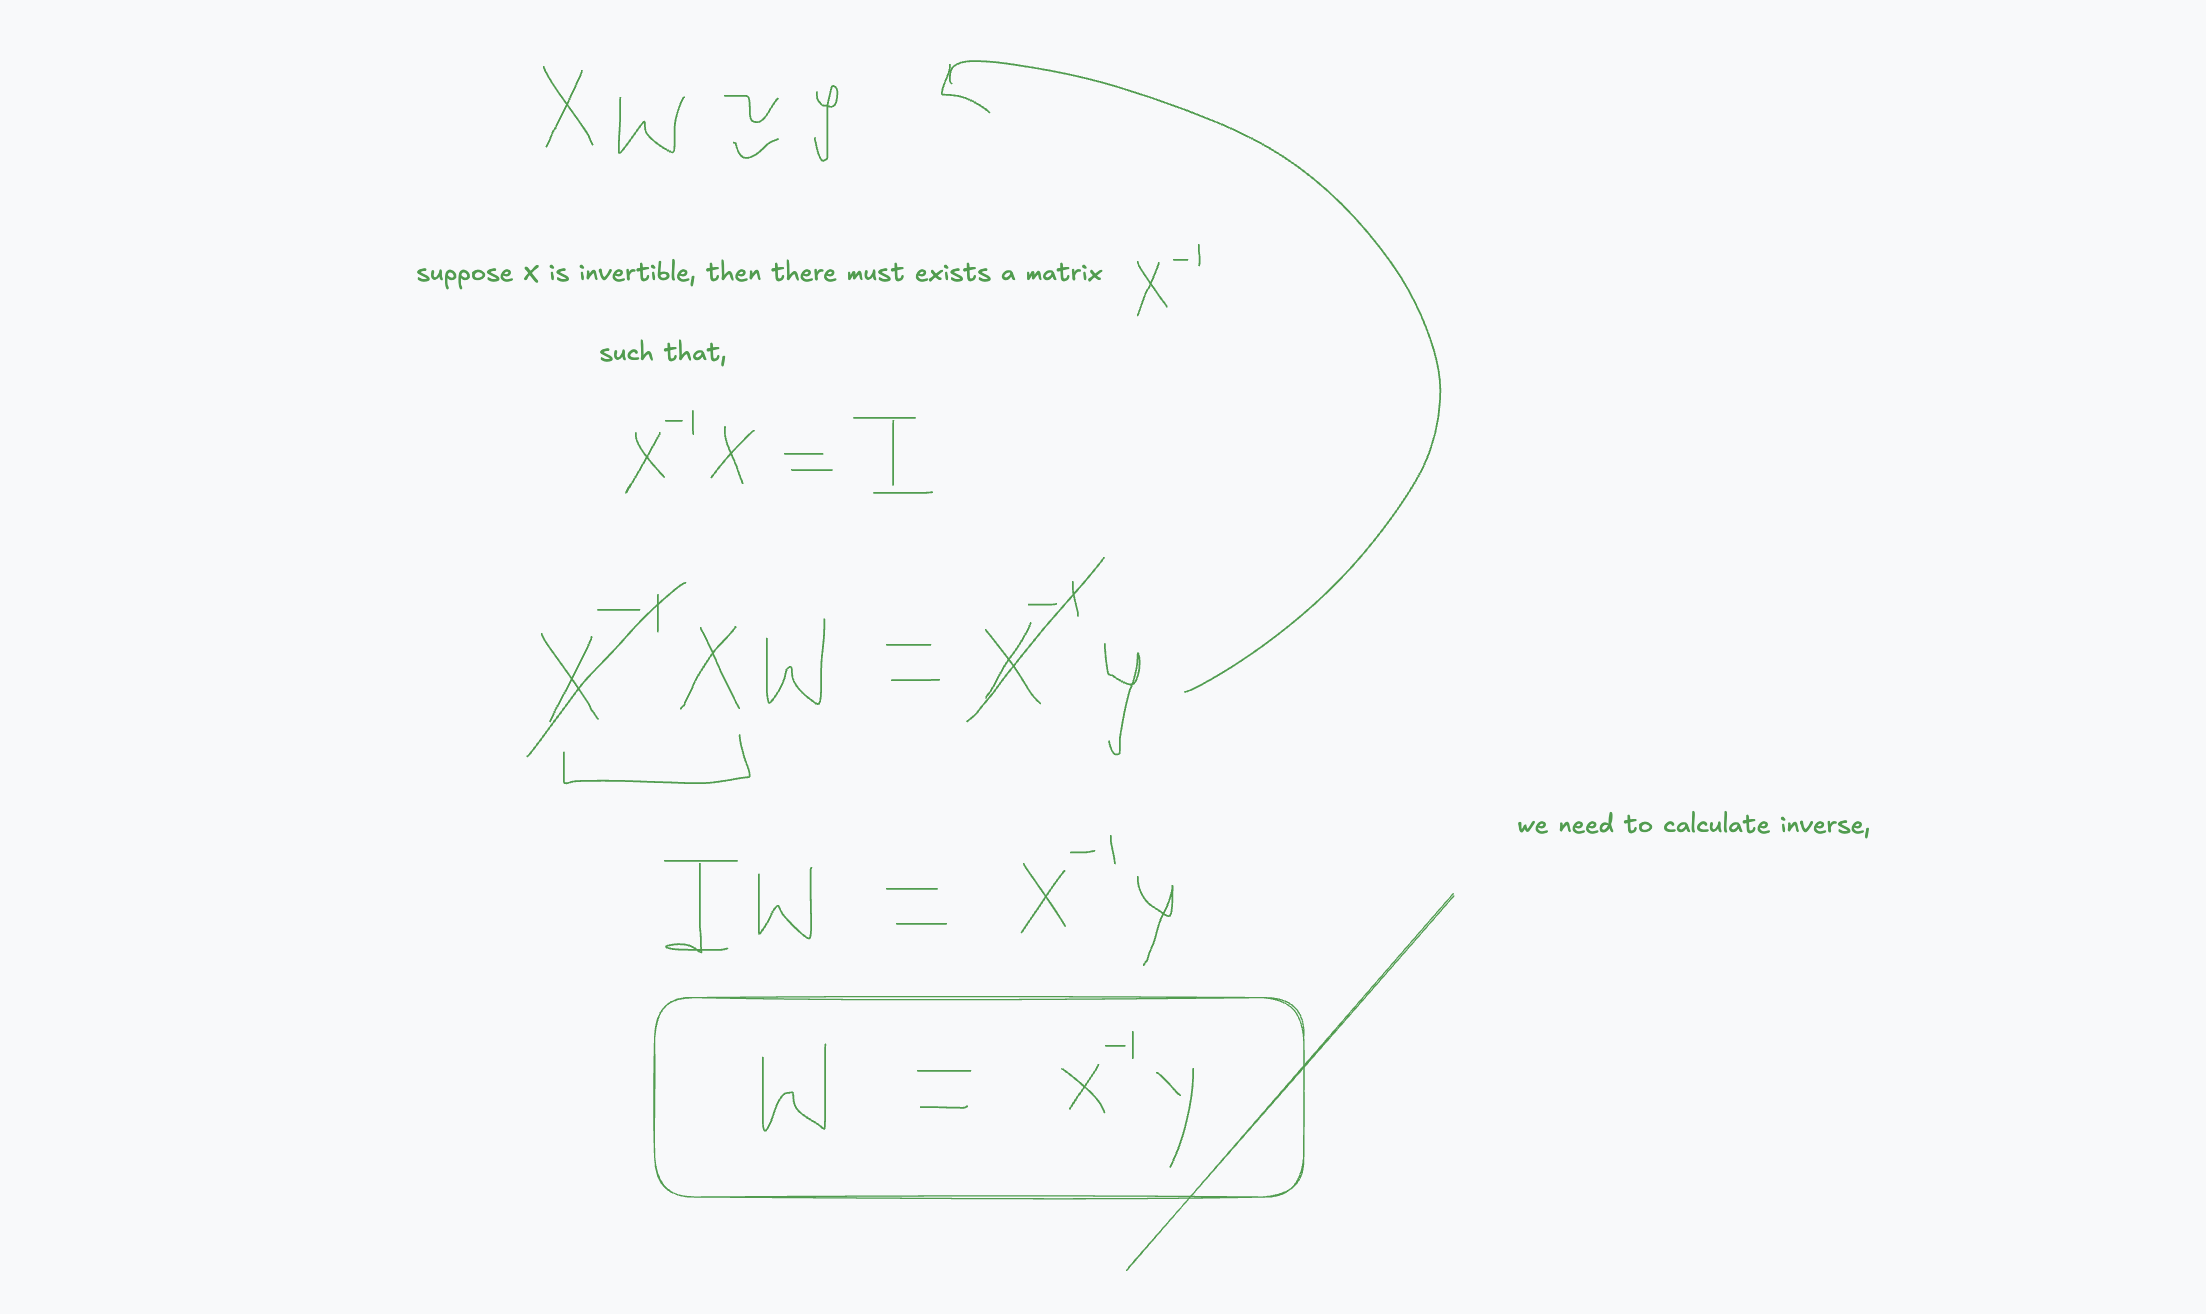

There is a problem which is a matrix is only invertible only when the matrix is square matrix, but in our use case, there can a numbers of records, that may not be same as its feature columns,
i.e rectangular feature matrix and weight.

Thoug we cant find inverse matrix for our usecase, can we move forward with Gram Matrix?

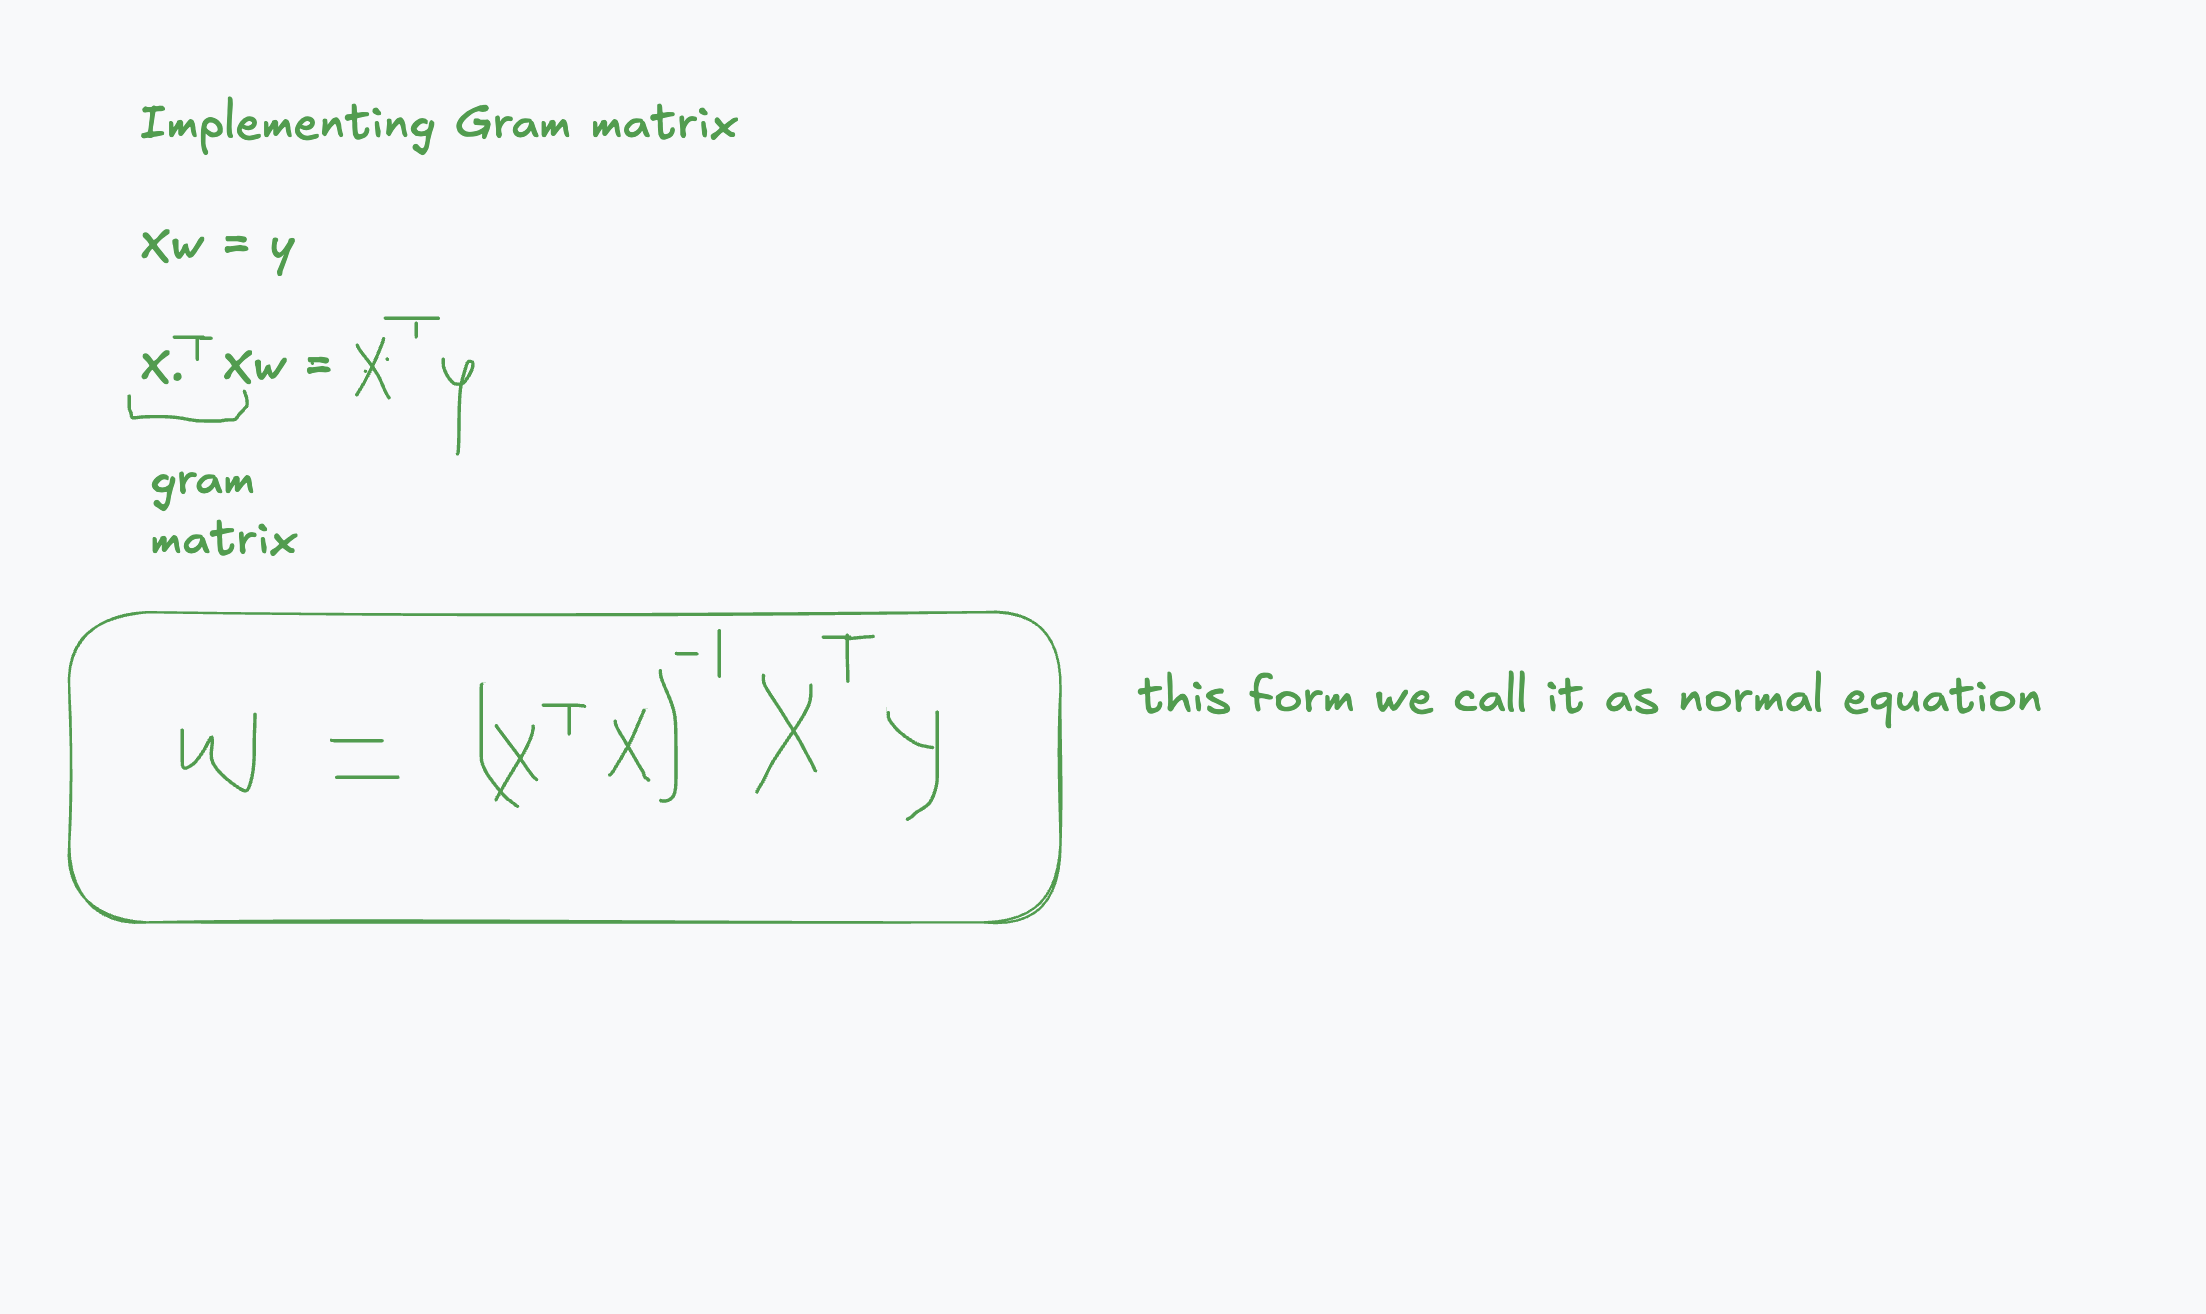

In [58]:
#@ Implementing the normal equations

In [59]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

In [60]:
XTX = X.T.dot(X)

In [61]:
#@ Its inverse
XTX_inv = np.linalg.inv(XTX)

we can quickly test, that the inverse is correct: multiplying Gram matrix by its inverse should give the identity matrix

In [62]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

we need the target values y. lets take the values of y randomy

In [63]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [64]:
#the normal equation gives us the weights

w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([0.26190562, 3.06101252, 0.03696909])

With this matrix, we already forgot about one thing. that is bias term.,the bias is important as it gives the price of a car even when we know nothing about the car. i.e w0, thus we need to add a column of ones to X and repeat the steps.

In [65]:
ones = np.ones((X.shape[0]))
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [66]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)

In [67]:
w_full

array([ 3.00067767e+02, -2.27742529e-01, -2.57694130e+00, -2.30120640e-02])

In [68]:
w0 = w_full[0]
w = w_full[1:]

In [69]:
#@ Lets implement above login into a function
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

We observed that the negative values of weight here in the arrays. that implies, as the feature grows, the predicted price goes down.

example: as the age of the car increases, the price decreses.

Lets move on to our core dataset, car price data to build our first model

- It is the simple version as we will only be dealing with numerical features, so its quality is the reference point we will try to improve.

Selecting the base features

In [70]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,54900
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,29215
7147,gmc,sierra_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,22,17,549,34675
7148,rolls-royce,ghost,2014,premium_unleaded_(required),563.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,sedan,21,13,86,303300


In [71]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

Lets consider only numbers,
- engine_hp
- engine_cylinders
- highway_mpg
- city_mpg
- popularity

In [72]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [73]:
X_train = df_train[base].values
X_train

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]])

In [74]:
#@ Lets try to train the model right away

w0, w = train_linear_regression(X_train, y_train)

In [75]:
w0, w

(np.float64(nan), array([nan, nan, nan, nan, nan]))

We observed that, both the bias and the weights are nan, ie not a number.

In [76]:
df_train[base].isnull().sum()

,0
engine_hp,40
engine_cylinders,14
highway_mpg,0
city_mpg,0
popularity,0


we observed that, engine hp and engine cylinders have null values. The easiest way to deal the null values is replacing with zeroes.

In [77]:
X_train = df_train[base].fillna(0).values

A car with 0 hp doesnt exist, no engine has 0 cylinder, but still it works. It still works, we need to look into linear regression formula.

suppose, we have two features, and the first feature is missing

g(xi) = w0 + xi1.w1 + xi2.w2 (xi1 is missing)

= w0 + 0.w1 + xi2.w2

= w0 + xi2.w2

when xi1 is 0, then the term xi1.w1 disapperas, the model successfully ignores that feature.

In [78]:
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)

In [79]:
w0, w

(np.float64(7.927257388069986),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [80]:
y_pred = w0 + X_train.dot(w)

In [81]:
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111])

To see how our model worked, we need to plot them as a historgram and compare with the histrogram of the actual traget values. for this, we use the same function we used during eda

<Axes: ylabel='Count'>

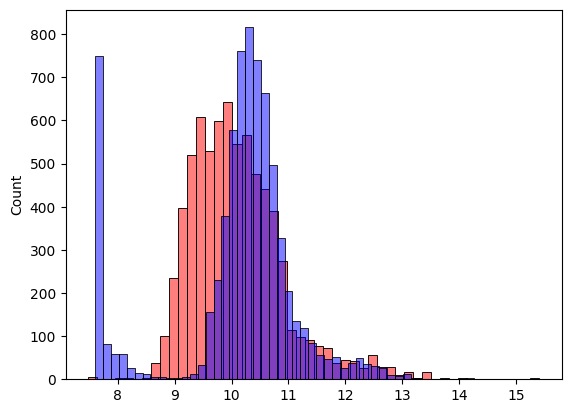

In [82]:
sns.histplot(y_pred, color = 'red', alpha=0.5, bins=50, label='predicted values')
sns.histplot(y_train, color = 'blue', alpha=0.5, bins=50, label='actual values')

just looking at the diagram, its difficult to interpret the model accuracy, thus we need to have a parameter, that can give us evaluation comparision

For the case of prediction Model, we have one popular matrix, which is

RMSE. Root Mean Square Error
- It gives the difference between prediction and actual values.
- For each observation i, g(xi) is the prediction we make and yi is the actual value.
- thus we take the difference, square it, taking average these squared differences over all the m obbservation.  Then finally, taking square root.

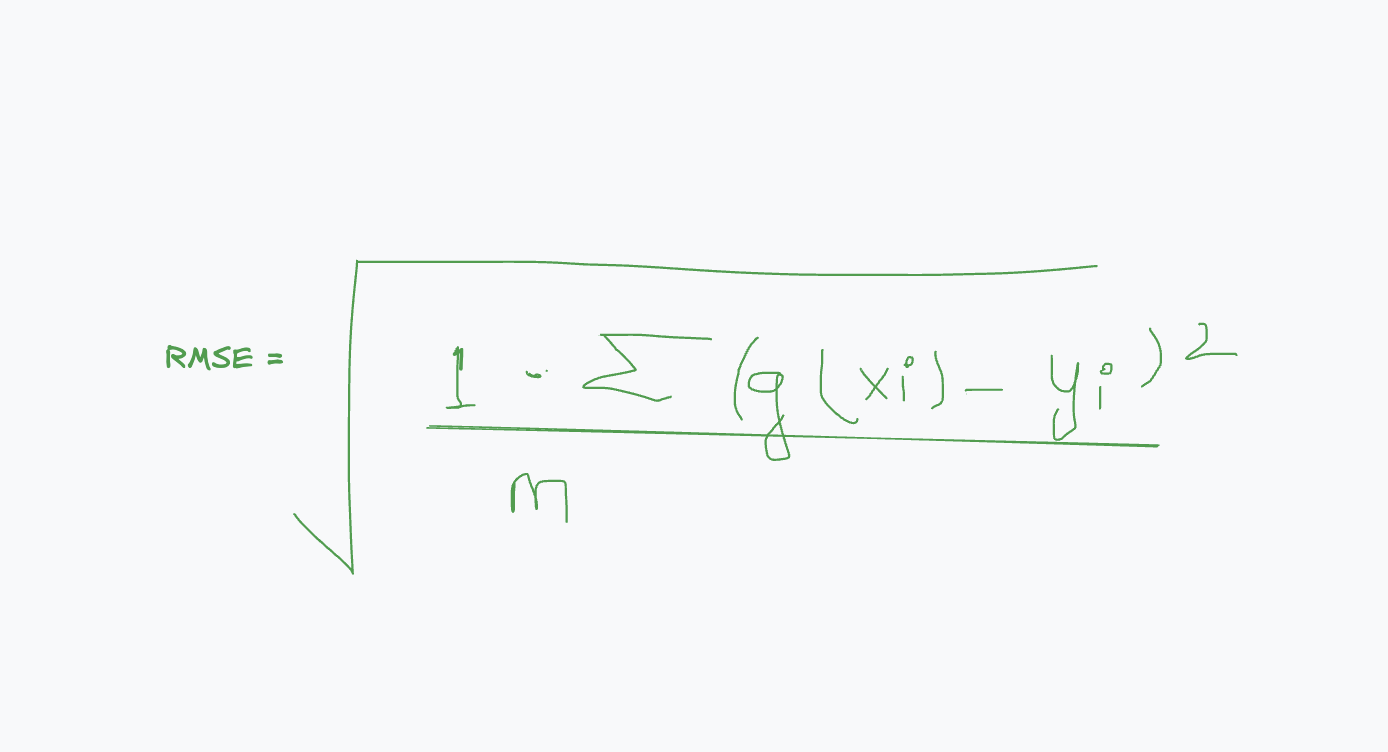

In [83]:
# y_pred: 10  9   11   10
# y:      9   9  10.5  11.5

In [84]:
# 1st step:
# 10 -9 = 1
# 9-9 = 0
# 11-10.5 = 0.5
# 10-11.5 = -1.5

In [85]:
# # 2nd step, square the result
# 1 -> 1
# 0 -> 0
# 0.5 - > 0.25
# -1.5 -> 2.25

square -> negative and postive erros comparable, also, it penalizes larger error more

In [86]:
(1+0+0.25+2.25) / 4

0.875

This is the mean square error (MSE) ERROR.

In [87]:
import math
math.sqrt(0.875)

0.9354143466934853

Thus, RMSE Error: 0.93

In [88]:
#@ Now implementing RMSE in our dataset after training

# def rmse(y, y_pred):
#     rmse = np.sqrt(np.mean((y - y_pred)**2))
#     return rmse

In [89]:
def rmse(y, y_pred):
  error = y - y_pred
  se = error ** 2
  mse = se.mean()
  return np.sqrt(mse)

In [90]:
#@ Simply implemeting RMSE in our trained data
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

Computing RMSE on validation data

So far, we trained the model and took out the RMSE Error, Now we need to check, how does our model work in the validation dataset

In [91]:
X_train = df_train[base].fillna(0).values

In [92]:
def prepare_X(df):
  df_num = df[base]
  df_num = df_num.fillna(0)
  X = df_num.values
  return X

It does following
- selects numerical columns,
- fills null values with 0
- extracts the feature matrix with numpy array and return it.

We can now tarin the model and validate it,. First the training part,
- we prepare the matrix from the training dataframe, and train the model.
- then validation part: we prepare the validation matrix, with the same function.. then we apply the model and compute the RMSE between actual values vs target values

In [93]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)

y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.761653099130156)

the numbers of rmse_val and rmse_train are quite similar, that means, the model behave on unseen data about as well the data it learned from.

**Feature Engineering**:
It is the process of creating a new feature from the ones we already have.
For our usecase, we will create a new feature called, feature engineering, then we will observe whether RMSE improves or not

In [94]:
2026 - df_train.year

,year
0,18
1,14
2,10
3,35
4,9
...,...
7145,11
7146,11
7147,11
7148,12


In [95]:
#@ this age, that can be used as a new feature.
# We add the feature age to prepare_X

In [96]:
def prepare_X(df):
  df['age'] = 2026 - df.year
  features = base + ['age']

  df_num = df[features]
  df_num = df_num.fillna(0)
  X = df_num.values
  return X

In [97]:
def prepare_X(df):
    df = df.copy()

    df['age'] = 2026 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

Now X_train has 6 columns,the five base columsn plus age which is the last one

In [98]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5172055461058305)

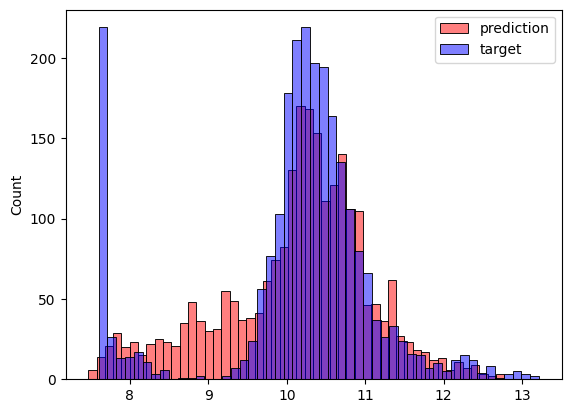

In [99]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()